# 04 - Debugging ML

Debugging ML systems can be a little strange, because most of the time you are likely not going to be fixing your actual code; instead, you are going to be working on fixing your data and your model parameters.

## Debug Order

Below is a good way to verify performance:

1. Data quality
2. Labels
3. Training behavior
4. Metrics
5. Deployment conditions

You can simplify this further to **data** (steps 1-2: is your input correct?) -> **performance** (steps 3-4: is your model learning and scoring well?) -> **generalizability** (step 5: does it hold up once deployed, on data it's never seen?).

## Visualizing Regression Errors: Residual Plots

Once your data and labels check out (steps 1-2 above) and your model has actually trained (step 3), the fastest way to dig into steps 4-5 - metrics and deployment conditions - is through visualization. We keep saying "always visualize your errors" - so let's actually do it. A **residual** is just the difference between the actual value and the model's prediction ($y - \hat{y}$). Plotting residuals is one of the fastest ways to spot a model that's gone wrong.

Let's bring back our AP Calculus example: a well-fit line model, and an overfit model that memorized every training point (like we saw in the Generalizability notebook). We'll look at how each one's residuals look on **new, unseen data**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(1515)

In [2]:
# recreate our familiar AP Calculus data
hours = np.linspace(0, 10, 50)
scores_good = 5 * hours + 50 + np.random.normal(0, 5, size=len(hours))
scores_new = 5 * hours + 50 + np.random.normal(0, 5, size=len(hours))  # a fresh, unseen sample from the SAME relationship

# a well-fit model (a line)
coeffs_good = np.polyfit(hours, scores_good, deg=1)
y_fit_good_line = np.poly1d(coeffs_good)(hours)

# an overfit model (fits every single training point)
overfit_model = interp1d(hours, scores_good, kind='cubic')
y_fit_overfit = overfit_model(hours)

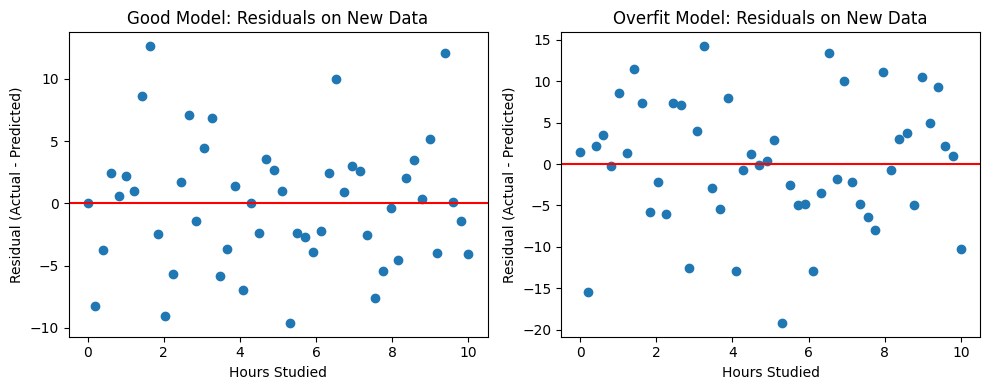

In [3]:
resid_good = scores_new - y_fit_good_line
resid_overfit = scores_new - y_fit_overfit

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(hours, resid_good)
plt.axhline(0, color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Good Model: Residuals on New Data")

plt.subplot(1, 2, 2)
plt.scatter(hours, resid_overfit)
plt.axhline(0, color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Overfit Model: Residuals on New Data")

plt.tight_layout()
plt.show()

A healthy residual plot looks like random scatter around zero, with no obvious pattern - that's what we see for the good model. The overfit model's residuals are much larger and swing wildly, because it memorized the training noise instead of the true trend, and that noise doesn't carry over to new data.

If you ever see a *pattern* in your residuals (e.g., they trend upward, or swing wildly like above), that's a signal something is systematically wrong - not just random error.

## Visualizing Classification Errors: Confusion Matrices

We introduced the confusion matrix in the Generalizability notebook as a way to *score* a classifier. It's just as useful as a *debugging* tool - the pattern of errors tells you what kind of mistake your model is making.

Suppose we have a game piece detector that struggles specifically in low light, and ends up missing a lot of real game pieces:

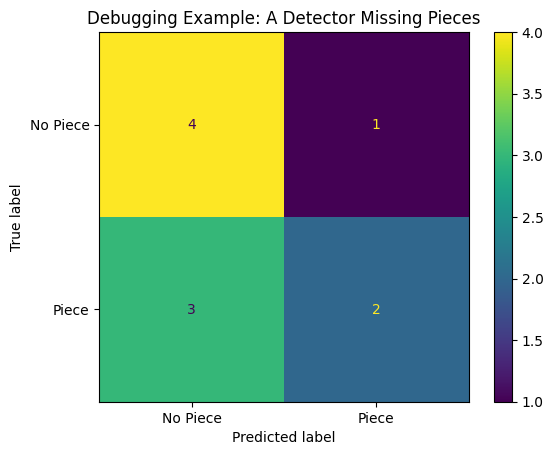

In [4]:
# a detector that misses several real game pieces (lots of False Negatives)
y_true = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
y_pred = [1, 0, 0, 1, 0, 0, 0, 0, 1, 0]

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Piece", "Piece"]).plot()
plt.title("Debugging Example: A Detector Missing Pieces")
plt.show()

Notice the False Negatives (bottom-left cell) - real game pieces the model is missing. The confusion matrix tells you *that* there's a problem, but not *why*.

The next step is to actually pull up the images behind those False Negatives and look at them: are they all taken in shadow? All at a certain distance or angle? This is what "always visualize your failure cases" really means in practice - the aggregate metric points you to a problem, and the individual examples tell you what to fix (better lighting in your training images, more examples at that distance, etc.).

If you cannot see your failures, you cannot fix them. Confusion matrices, residual plots, and just looking at raw failure cases will all have their place in your workflow.

## Try It Yourself

Change a few entries in `y_pred` in the confusion matrix example above so that the detector instead has a False Positive problem (frequently claiming "piece" when there isn't one) rather than a False Negative problem. Regenerate the confusion matrix. What kind of real-world cause might lead to *that* failure pattern instead (as opposed to missed detections)?

In [5]:
# TODO: edit y_pred above to create more False Positives, then regenerate the confusion matrix
